# Notebook 03 — Feature Engineering

**Goal**: Build 50+ predictive features from raw OHLCV data — with **zero look-ahead bias**.

---

## Feature Categories

| Category | # Features | Examples |
|----------|-----------|----------|
| **Technical** | ~35 | SMA, EMA, MACD, RSI, Bollinger, ATR, ADX |
| **Volatility** | ~5 | Garman-Klass, Parkinson, rolling std |
| **Volume** | ~5 | OBV, VWAP proxy, Force Index, volume ratio |
| **Cross-Asset** | ~8 | VIX, Nifty return, Gold, Crude, USD/INR |
| **Calendar** | ~12 | Day-of-week, month cycle, F&O expiry |
| **Lagged** | ~10 | 1/2/3-day lags of key features |

## Look-Ahead Bias Prevention

**Critical rule**: Every feature at time $t$ must use ONLY data from $t$ and before.

Examples of what we do:
- SMA(20) at day $t$ = mean of Close from $t-19$ to $t$ ✅
- RSI at day $t$ = based on returns up to day $t$ ✅

Examples of what we **never** do:
- Future return as feature ❌
- Rolling z-score using entire dataset ❌
- Centering features with full-sample mean ❌

Our pipeline includes a `verify_no_lookahead()` method that checks for this.

In [2]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import DataDownloader, DataCleaner
from src.features import FeaturePipeline
from src.features.technical import TechnicalFeatures
from src.features.cross_asset import CrossAssetFeatures
from src.features.calendar_features import CalendarFeatures
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Cleaned Data

We start from the cleaned data produced in Notebook 02.

In [3]:
# Load cleaned data from interim/
interim_dir = DATA_DIR / "interim"
parquet_files = list(interim_dir.glob("*.parquet"))

cleaned_data = {}
for f in parquet_files:
    ticker = f.stem.replace("_NS", ".NS").replace("_", ".")
    cleaned_data[ticker] = pd.read_parquet(f)

print(f"Loaded {len(cleaned_data)} cleaned tickers")

# Pick a demo ticker for step-by-step visualization
demo_ticker = "RELIANCE.NS"
if demo_ticker not in cleaned_data:
    demo_ticker = list(cleaned_data.keys())[0]
demo_df = cleaned_data[demo_ticker].copy()
print(f"\nDemo ticker: {demo_ticker} ({len(demo_df)} rows)")
demo_df.head()

Loaded 122 cleaned tickers

Demo ticker: RELIANCE.NS (2469 rows)


Price,Close,High,Low,Open,Volume,Returns,Log_Returns
Date,,,,,,,
2016-02-15,205.145477,206.142224,198.915819,198.915819,19283523,NaN,NaN
2016-02-16,201.635239,207.583202,200.866004,206.088082,13024856,-0.017111,-0.017259
2016-02-17,206.413101,207.464017,198.569136,202.621125,15442221,0.023696,0.023419
2016-02-18,203.704559,209.901716,202.816152,208.655776,14433087,-0.013122,-0.013209
2016-02-19,204.625443,206.445593,203.108655,203.682880,10235503,0.004521,0.004510


## Step 2 — Technical Features (Deep Dive)

### Moving Averages
- **SMA(n)**: Simple Moving Average — equal weight to last n days
- **EMA(n)**: Exponential Moving Average — more weight to recent days
- **SMA ratio**: Close / SMA(n) — measures deviation from trend

### Momentum Indicators
- **RSI(14)**: Relative Strength Index — overbought (>70) / oversold (<30)
- **MACD**: Moving Average Convergence Divergence — trend direction & strength
- **ADX(14)**: Average Directional Index — trend strength (>25 = trending)
- **Stochastic**: Compares close to range — overbought/oversold
- **Williams %R**: Similar to stochastic, oscillates -100 to 0
- **CCI**: Commodity Channel Index — cycles detection
- **ROC(n)**: Rate of Change — return over n days
- **MFI**: Money Flow Index — volume-weighted RSI

### Volatility Indicators
- **Bollinger Bands**: ±2σ bands around SMA(20)
- **ATR(14)**: Average True Range — daily volatility
- **Garman-Klass**: Uses OHLC for better vol estimate than close-to-close
- **Parkinson**: Uses high-low range for intraday vol

### Volume Indicators
- **OBV**: On-Balance Volume — cumulative volume direction
- **VWAP proxy**: Volume-weighted average price
- **Force Index**: Price change × volume

In [4]:
# Apply technical features to demo ticker
demo_tech = TechnicalFeatures.compute_all(demo_df.copy())

print(f"Original columns: {len(demo_df.columns)}")
print(f"After technical:  {len(demo_tech.columns)}")
print(f"New features:     {len(demo_tech.columns) - len(demo_df.columns)}")

# List all technical features
tech_features = [c for c in demo_tech.columns if c not in demo_df.columns]
print(f"\nTechnical features ({len(tech_features)}):")
for i, f in enumerate(tech_features, 1):
    print(f"  {i:2d}. {f}")

Original columns: 7
After technical:  75
New features:     68

Technical features (68):
   1. SMA_5
   2. Close_SMA_5_ratio
   3. SMA_10
   4. Close_SMA_10_ratio
   5. SMA_20
   6. Close_SMA_20_ratio
   7. SMA_50
   8. Close_SMA_50_ratio
   9. SMA_200
  10. Close_SMA_200_ratio
  11. EMA_12
  12. EMA_26
  13. MACD
  14. MACD_Signal
  15. MACD_Histogram
  16. ADX
  17. Plus_DI
  18. Minus_DI
  19. RSI
  20. Stochastic_K
  21. Stochastic_D
  22. Williams_R
  23. CCI
  24. ROC_1
  25. ROC_5
  26. ROC_10
  27. ROC_21
  28. MFI
  29. BB_Upper
  30. BB_Lower
  31. BB_Width
  32. BB_Position
  33. ATR
  34. ATR_pct
  35. Volatility_5d
  36. Volatility_10d
  37. Volatility_21d
  38. Volatility_63d
  39. GK_Volatility
  40. Parkinson_Vol
  41. HL_Range_pct
  42. CO_Range_pct
  43. Gap_pct
  44. OBV
  45. Volume_SMA_ratio
  46. VWAP_proxy
  47. Close_VWAP_ratio
  48. Force_Index
  49. Force_Index_13
  50. AD_Line
  51. CMF_21
  52. Volume_ROC_5
  53. RVOL
  54. ADX_Smooth_14
  55. Mean_Reversion_

## Step 3 — Visualize Key Technical Features

Let's plot a few features on the demo ticker to understand what they capture.

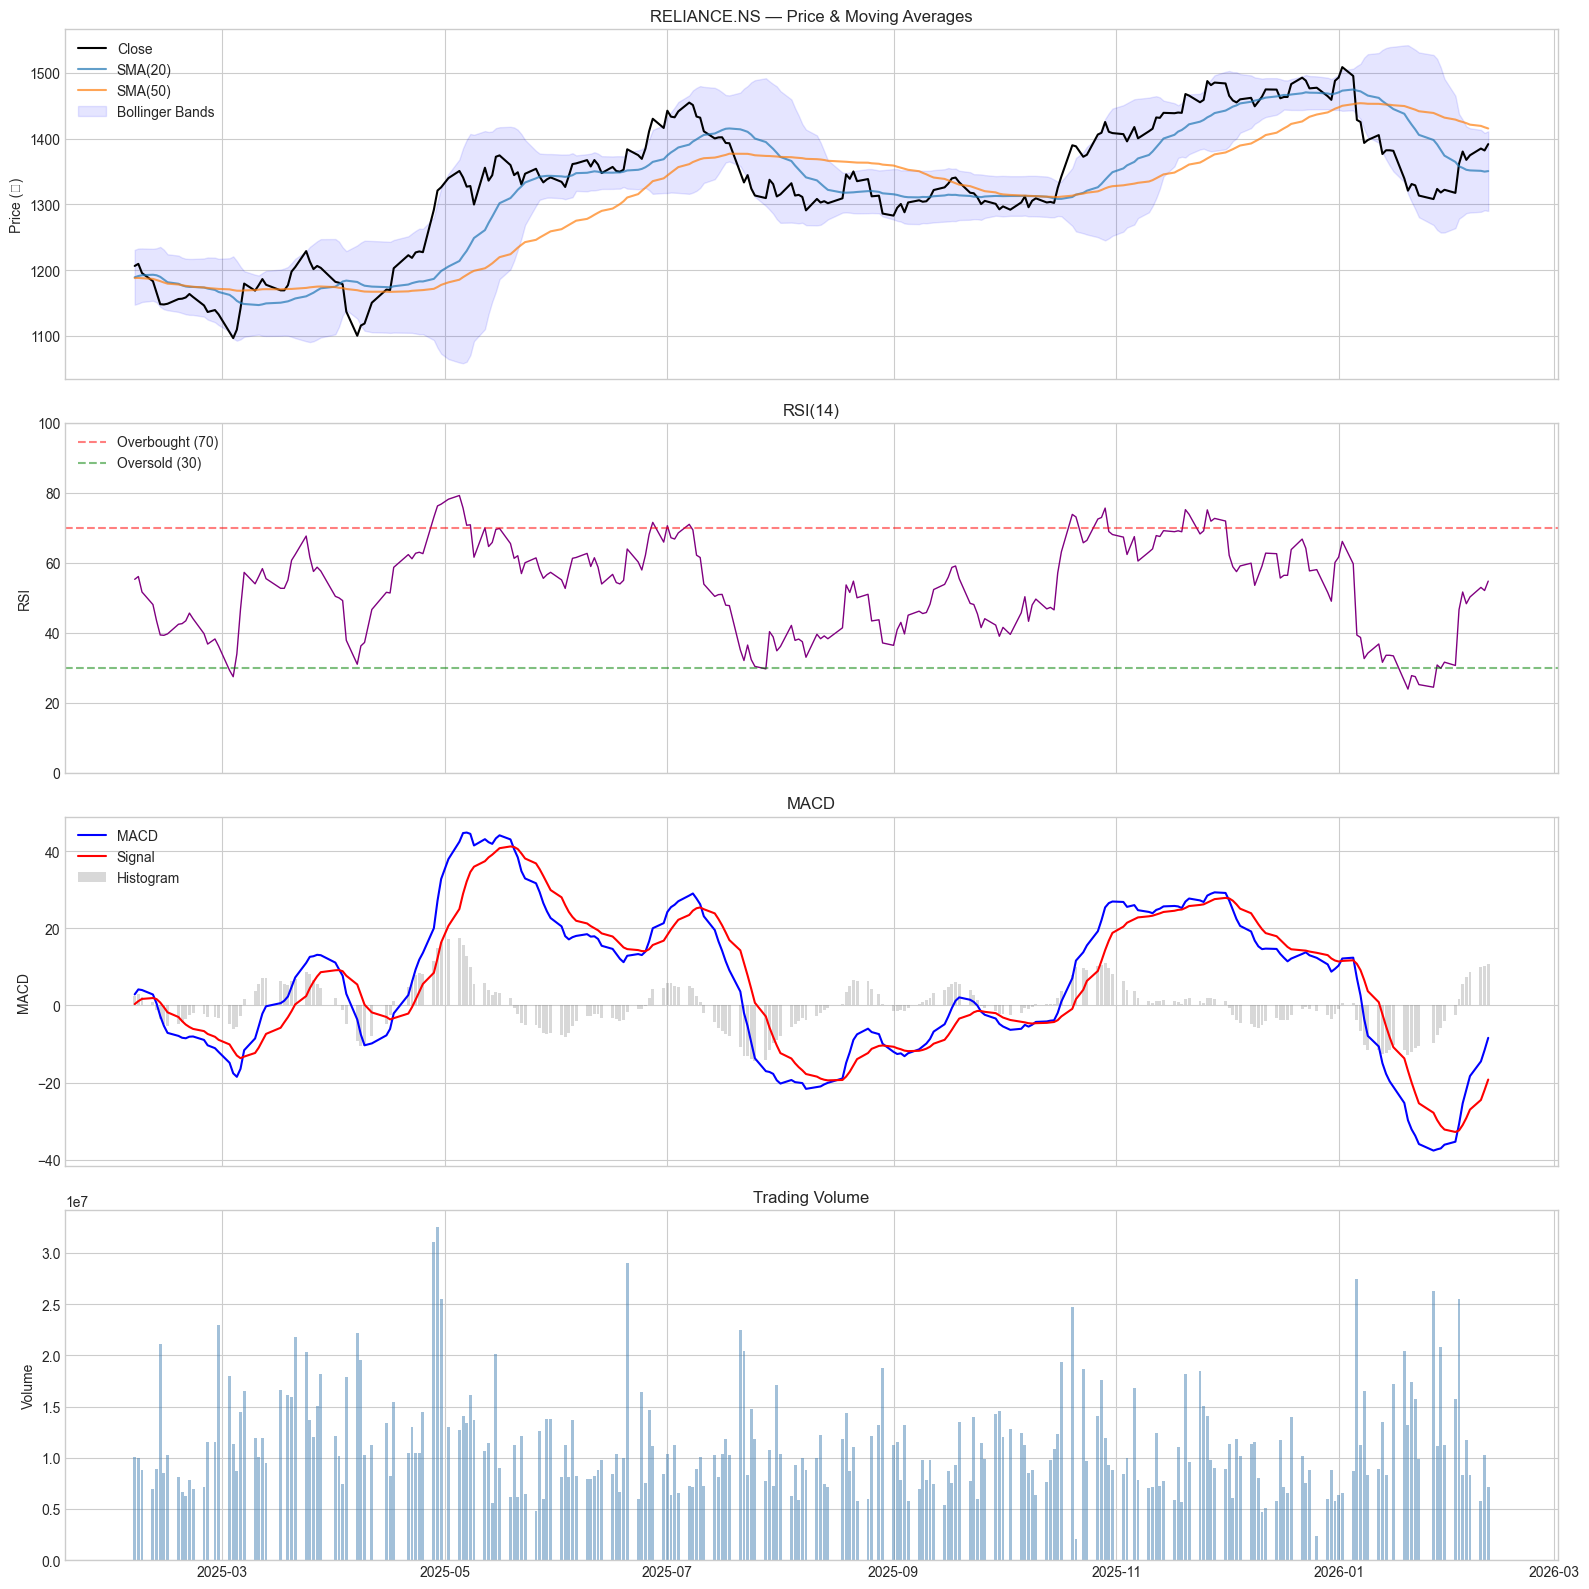

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
last_year = demo_tech.iloc[-252:]  # Last year of data

# 1. Price with SMAs
axes[0].plot(last_year.index, last_year["Close"], label="Close", color="black", lw=1.5)
if "SMA_20" in last_year.columns:
    axes[0].plot(last_year.index, last_year["SMA_20"], label="SMA(20)", alpha=0.7)
if "SMA_50" in last_year.columns:
    axes[0].plot(last_year.index, last_year["SMA_50"], label="SMA(50)", alpha=0.7)
if "BB_Upper" in last_year.columns:
    axes[0].fill_between(last_year.index, last_year["BB_Upper"], last_year["BB_Lower"],
                         alpha=0.1, color="blue", label="Bollinger Bands")
axes[0].set_ylabel("Price (₹)")
axes[0].set_title(f"{demo_ticker} — Price & Moving Averages")
axes[0].legend(loc="upper left")

# 2. RSI
if "RSI" in last_year.columns:
    axes[1].plot(last_year.index, last_year["RSI"], color="purple", lw=1)
    axes[1].axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
    axes[1].axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
    axes[1].set_ylabel("RSI")
    axes[1].set_title("RSI(14)")
    axes[1].legend(loc="upper left")
    axes[1].set_ylim(0, 100)

# 3. MACD
if "MACD" in last_year.columns and "MACD_Signal" in last_year.columns:
    axes[2].plot(last_year.index, last_year["MACD"], label="MACD", color="blue")
    axes[2].plot(last_year.index, last_year["MACD_Signal"], label="Signal", color="red")
    if "MACD_Histogram" in last_year.columns:
        axes[2].bar(last_year.index, last_year["MACD_Histogram"], alpha=0.3, color="gray", label="Histogram")
    axes[2].set_ylabel("MACD")
    axes[2].set_title("MACD")
    axes[2].legend(loc="upper left")

# 4. Volume
axes[3].bar(last_year.index, last_year["Volume"], alpha=0.5, color="steelblue")
axes[3].set_ylabel("Volume")
axes[3].set_title("Trading Volume")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "technical_features_demo.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Cross-Asset Features

Individual stock returns are influenced by macro factors:

- **VIX**: When fear is high (VIX > 20), stocks tend to fall together
- **Nifty returns**: The overall market direction affects most stocks
- **Gold**: Inverse correlation during crises
- **Crude oil**: Affects inflation expectations and energy stocks
- **USD/INR**: Weak rupee hurts IT importers, helps IT exporters

In [6]:
cross = CrossAssetFeatures()
demo_cross = cross.compute(demo_tech.copy())

cross_features = [c for c in demo_cross.columns if c not in demo_tech.columns]
print(f"Cross-asset features ({len(cross_features)}):")
for f in cross_features:
    print(f"  • {f}")

Cross-asset features (14):
  • Nifty_Return_1d
  • Nifty_Return_5d
  • BankNifty_Return_1d
  • BankNifty_Return_5d
  • VIX_Level
  • VIX_Change
  • VIX_SMA5_ratio
  • VIX_Percentile
  • USDINR_Return_1d
  • USDINR_Return_5d
  • Gold_Return_1d
  • Gold_Return_5d
  • Crude_Return_1d
  • Crude_Return_5d


## Step 5 — Calendar Features

Markets exhibit calendar effects:
- **Day-of-week**: Monday tends to be slightly negative, Friday positive
- **Month-end/Quarter-end**: Fund rebalancing causes extra volume
- **F&O expiry**: Thursday expiry week has higher volatility
- **Budget**: Union Budget week has high uncertainty
- **Year-end**: Tax-loss selling in March

In [7]:
cal = CalendarFeatures()
demo_cal = cal.compute(demo_cross.copy())

cal_features = [c for c in demo_cal.columns if c not in demo_cross.columns]
print(f"Calendar features ({len(cal_features)}):")
for f in cal_features:
    print(f"  • {f}")

Calendar features (16):
  • DayOfWeek_Mon
  • DayOfWeek_Tue
  • DayOfWeek_Wed
  • DayOfWeek_Thu
  • DayOfWeek_Fri
  • Month_sin
  • Month_cos
  • WeekOfYear_sin
  • WeekOfYear_cos
  • IsMonthEnd
  • IsMonthStart
  • IsQuarterEnd
  • DaysToExpiry
  • IsExpiryWeek
  • IsBudgetWeek
  • IsYearEnd


## Step 6 — Full Feature Pipeline

The `FeaturePipeline` orchestrates all feature computation in order:

1. Technical features
2. Cross-asset features
3. Calendar features
4. Rolling z-score normalization (252-day window)
5. Lag features (1, 2, 3 days)
6. Drop warmup period (first 252 days)
7. Drop highly correlated features (|ρ| > 0.95)

Let's run it on all tickers and save to `data/processed/`

In [8]:
pipeline = FeaturePipeline()

# Process all tickers — DO NOT drop correlated features per-ticker
# This ensures all tickers have the SAME feature columns, which is critical
# for consistent model training. Correlation-based filtering is handled
# during training (NB05/NB06) on the combined panel data instead.
processed_data = {}
for i, (ticker, df) in enumerate(cleaned_data.items()):
    if i % 20 == 0:
        print(f"Processing {i+1}/{len(cleaned_data)}...")
    try:
        result = pipeline.run_single(df.copy(), ticker, drop_correlated=False)
        if result is not None and len(result) > 100:
            processed_data[ticker] = result
            safe_name = ticker.replace("^", "IDX_").replace("=", "_")
            result.to_parquet(DATA_DIR / "processed" / f"{safe_name}.parquet")
    except Exception as e:
        print(f"  ⚠️ {ticker}: {e}")

print(f"\n✅ Processed {len(processed_data)} tickers")

# Show feature count for demo ticker
if demo_ticker in processed_data:
    demo_final = processed_data[demo_ticker]
    print(f"\n{demo_ticker}: {len(demo_final)} rows × {len(demo_final.columns)} features")

Processing 1/122...
Processing 21/122...
Processing 41/122...
Processing 61/122...
Processing 81/122...
Processing 101/122...
Processing 121/122...

✅ Processed 122 tickers

RELIANCE.NS: 2269 rows × 226 features


## Step 7 — Verify No Look-Ahead Bias

The pipeline has a built-in verification method.
It checks that no feature at time $t$ correlates suspiciously with future returns.

In [9]:
if demo_ticker in processed_data:
    feature_cols = pipeline.get_feature_columns(processed_data[demo_ticker])
    result = pipeline.verify_no_lookahead(processed_data[demo_ticker], feature_cols)
    if result["status"] == "PASS":
        print(f"✅ No look-ahead bias detected! ({result['n_valid']}/{result['n_features']} features valid at {result['date']})")
    else:
        print(f"⚠️ {result['status']} — investigate!")

✅ No look-ahead bias detected! (206/206 features valid at 2023-05-15 00:00:00)


## Step 8 — Feature Statistics & Correlation

Let's look at feature distributions and correlations to understand what we built.

In [10]:
if demo_ticker in processed_data:
    demo_final = processed_data[demo_ticker]
    
    # Feature stats
    stats = demo_final.describe().T
    stats["missing_pct"] = demo_final.isnull().mean() * 100
    print("Feature Statistics (top 20):")
    print(stats[["mean", "std", "min", "max", "missing_pct"]].head(20).round(4))
    
    # Correlation with target
    # The target is future return — let's compute it for analysis
    future_ret = demo_final["Close"].pct_change(5).shift(-5)  # 5-day forward return
    feature_cols = [c for c in demo_final.columns if c not in 
                    ["Open", "High", "Low", "Close", "Volume", "Adj Close"]]
    
    correlations = demo_final[feature_cols].corrwith(future_ret).dropna().abs().sort_values(ascending=False)
    
    print(f"\nTop 15 features correlated with 5-day forward return:")
    for feat, corr in correlations.head(15).items():
        print(f"  {feat:30s} |ρ| = {corr:.4f}")
    
    print(f"\n💡 Low correlations are expected! If any feature had |ρ| > 0.5,")
    print(f"   it would be suspicious (possible look-ahead bias or overfitting).")

Feature Statistics (top 20):
                             mean           std       min           max  \
Price                                                                     
Close                8.774250e+02  3.649881e+02  222.6077  1.508568e+03   
High                 9.305348e+02  3.940838e+02  225.4343  1.611800e+03   
Low                  8.770417e+02  3.654025e+02  221.9284  1.508568e+03   
Open                 9.214839e+02  3.913260e+02  222.8487  1.593000e+03   
Volume               1.815499e+07  1.390916e+07    0.0000  1.426834e+08   
Returns              9.000000e-04  1.660000e-02   -0.0838  8.560000e-02   
Log_Returns          8.000000e-04  1.660000e-02   -0.0875  8.220000e-02   
SMA_5                8.763985e+02  3.649714e+02  221.1921  1.495844e+03   
Close_SMA_5_ratio    1.001700e+00  1.850000e-02    0.8940  1.088400e+00   
SMA_10               8.751316e+02  3.650234e+02  219.4326  1.491250e+03   
Close_SMA_10_ratio   1.003800e+00  2.840000e-02    0.8484  1.114800e+00

## ✅ Feature Engineering Complete!

**What we built:**
1. 50+ technical, cross-asset, and calendar features
2. Rolling z-score normalization (no future data used)
3. Lag features to add temporal context
4. Dropped warmup period and highly-correlated features
5. Verified zero look-ahead bias

**Processed data saved to:** `data/processed/`

**Next:** Proceed to **Notebook 04 — Walk-Forward Cross-Validation**

---
*Educational project. Not financial advice.*